25 Dec 2025

Spanning Trajectories

In [6]:
#filename
file_name = "2d_v6_data_gen_test_landscape"

#basic_operations
import os
import math
import pickle

#exploratory_data_analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from numpy.fft import fft, fftfreq

#data_generation 
from scipy.interpolate import splprep, splev

#deep_learning
import torch
import torch.nn as nn
from complexPyTorch.complexLayers import ComplexLinear, ComplexReLU
from torch.utils.data import TensorDataset, DataLoader, random_split

#gpu_usage
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist

#random_seed
torch.manual_seed(42)
np.random.seed(42)

# Constants
epsilon = 1e-10

#math
from sympy import diff

In [7]:
# Check if CUDA is available
print("Is CUDA available?", torch.cuda.is_available())

# Total number of GPUs available
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")

# List all GPU names
for i in range(num_gpus):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


Is CUDA available? True
Number of GPUs available: 8
GPU 0: NVIDIA H100 80GB HBM3
GPU 1: NVIDIA H100 80GB HBM3
GPU 2: NVIDIA H100 80GB HBM3
GPU 3: NVIDIA H100 80GB HBM3
GPU 4: NVIDIA H100 80GB HBM3
GPU 5: NVIDIA H100 80GB HBM3
GPU 6: NVIDIA H100 80GB HBM3
GPU 7: NVIDIA H100 80GB HBM3


In [8]:
# Preliminaries

# Distance - meters
# Angle - Radians
# Time - seconds

# Simulation Parameters

dt = 0.01
total_time = 10
time_series = np.arange(0, total_time, dt)
total_time_steps = len(time_series)

# Environment Parameters

grid_min, grid_max = 0, 1
step_size = 0.2 #distance after which angle changes.
lookahead = 1.7 # no of steps to lookahead to prevent boundary issues


In [ ]:
# Code for Random Trajectories:

'''
def get_future_pos(x_current, y_current, head_dir_current):
  x_future = x_current + lookahead * step_size * math.cos(head_dir_current)
  y_future = y_current + lookahead * step_size * math.sin(head_dir_current)
  return x_future, y_future

def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def choose_head_dir(x_current, y_current, head_dir_current):

    num_tries = 30

    # Angle tiers (in degrees)
    tier_small  = np.concatenate([np.arange(-30, 0), np.arange(0, 30)])
    tier_medium = np.concatenate([np.arange(-60, -30), np.arange(30, 60)])
    tier_large  = np.concatenate([np.arange(-90, -60), np.arange(60, 90)])
    tier_escape = np.concatenate([np.arange(-120, -90), np.arange(90, 120)])
    tier_uturn  = np.concatenate([np.arange(-150, -120), np.arange(120, 150)])


    tiers = [tier_small, tier_medium, tier_large]
    tiers = np.array(tiers)

    
    # Try first random tier
    for tier in np.random.permutation(tiers):
        # small randomisation within tier
        #np.random.shuffle(tier)
        for dir in np.random.permutation(tier):
            delta = math.radians(dir)
            head_dir_next = wrap_angle(head_dir_current + delta)
            x_future, y_future = get_future_pos(x_current, y_current, head_dir_next)
            if grid_min < x_future < grid_max and grid_min < y_future < grid_max:
                return x_future, y_future, head_dir_next
            
    for dir in np.random.permutation(tier_escape):
            delta = math.radians(dir)
            head_dir_next = wrap_angle(head_dir_current + delta)
            x_future, y_future = get_future_pos(x_current, y_current, head_dir_next)
            if grid_min < x_future < grid_max and grid_min < y_future < grid_max:
                return x_future, y_future, head_dir_next
    

    
    raise ValueError("No smooth head direction found within boundaries")


# Trajectory generation

def generate_trajectory(velocity):
    x_sharp = []
    y_sharp = []
    head_dir = []
    x_initial, y_initial = np.random.uniform(0.1, 0.9, size=2)
    initial_positions = (x_initial, y_initial)
    head_dir_initial = np.random.uniform(-np.pi, np.pi)
    distance = velocity * total_time
    num_steps = np.floor(distance / step_size)

    for i in range(int(num_steps)):
        if i == 0:
            head_dir_current = head_dir_initial
            x_current, y_current = x_initial, y_initial
            x_sharp.append(x_current)
            y_sharp.append(y_current)
            head_dir.append(head_dir_current)
        
        x_future, y_future, head_dir_next = choose_head_dir(x_current, y_current, head_dir_current)
        x_next = x_current + step_size * math.cos(head_dir_next)
        y_next = y_current + step_size * math.sin(head_dir_next)
        
        head_dir_current = head_dir_next
        x_current, y_current = x_next, y_next

        x_sharp.append(x_current)
        y_sharp.append(y_current)
        head_dir.append(head_dir_current)


    x_sharp = np.array(x_sharp)
    y_sharp = np.array(y_sharp)
    head_dir = np.array(head_dir)
    initial_positions = np.array(initial_positions)
    #print(X.shape, Y.shape, HD.shape, initial_positions.shape)    
    return initial_positions, x_sharp, y_sharp    

# Smoothening the random trajectories

def resample_spline_by_arclength(tck, n_points):
    # dense sampling for arc-length estimation
    u_dense = np.linspace(0, 1, max(1000, n_points*5))
    x_dense, y_dense = splev(u_dense, tck)
    
    # estimate arc length along the dense sampling
    dx = np.diff(x_dense)
    dy = np.diff(y_dense)
    ds = np.sqrt(dx*dx + dy*dy)
    s = np.concatenate([[0], np.cumsum(ds)])   # cumulative arc-length

    # normalize to [0,1]
    s = s / s[-1]

    # new u values uniformly spaced in arc-length
    s_uniform = np.linspace(0, 1, n_points)
    u_uniform = np.interp(s_uniform, s, u_dense)

    return u_uniform


def generate_smooth_trajectory(velocity):

    initial_positions, x_sharp, y_sharp = generate_trajectory(velocity)
    # s = smoothing factor, larger = smoother
    tck, u = splprep([x_sharp, y_sharp], s=0, k=3)

    u_new = resample_spline_by_arclength(tck, n_points=total_time_steps)
    
    x_smooth, y_smooth = splev(u_new, tck)
    # check if all points are in the boundaries
    for x, y in zip(x_smooth, y_smooth):
        if not (grid_min < x < grid_max and grid_min < y < grid_max):
            raise ValueError("Trajectory point out of bounds")
    return initial_positions, x_smooth, y_smooth

'''


In [21]:
# Spanning trajectories of 6 patterns

def generate_spiral_from_center(total_time_steps):
    """Generate an outward spiral starting from the center."""
    t = np.linspace(0, 4*np.pi, total_time_steps)
    radius = np.linspace(0.05, 0.45, total_time_steps)
    x = 0.5 + radius * np.cos(t)
    y = 0.5 + radius * np.sin(t)
    return x, y

def generate_spiral_from_boundary(total_time_steps):
    """Generate an inward spiral starting from near the boundary."""
    t = np.linspace(0, 4*np.pi, total_time_steps)
    radius = np.linspace(0.45, 0.05, total_time_steps)
    x = 0.5 + radius * np.cos(t)
    y = 0.5 + radius * np.sin(t)
    return x, y

def generate_horizontal_zigzag_lr(total_time_steps, n_passes=10):
    """Generate horizontal zigzag from left to right."""
    y_positions = np.linspace(0.1, 0.9, n_passes)
    x, y = [], []
    points_per_pass = total_time_steps // n_passes
    
    for i, y_pos in enumerate(y_positions):
        if i % 2 == 0:
            x_pass = np.linspace(0.05, 0.95, points_per_pass)
        else:
            x_pass = np.linspace(0.95, 0.05, points_per_pass)
        y_pass = np.full(points_per_pass, y_pos)
        x.extend(x_pass)
        y.extend(y_pass)
    
    x = np.array(x[:total_time_steps])
    y = np.array(y[:total_time_steps])
    if len(x) < total_time_steps:
        x = np.pad(x, (0, total_time_steps - len(x)), mode='edge')
        y = np.pad(y, (0, total_time_steps - len(y)), mode='edge')
    return x, y

def generate_horizontal_zigzag_rl(total_time_steps, n_passes=10):
    """Generate horizontal zigzag from right to left."""
    y_positions = np.linspace(0.1, 0.9, n_passes)
    x, y = [], []
    points_per_pass = total_time_steps // n_passes
    
    for i, y_pos in enumerate(y_positions):
        if i % 2 == 0:
            x_pass = np.linspace(0.95, 0.05, points_per_pass)
        else:
            x_pass = np.linspace(0.05, 0.95, points_per_pass)
        y_pass = np.full(points_per_pass, y_pos)
        x.extend(x_pass)
        y.extend(y_pass)
    
    x = np.array(x[:total_time_steps])
    y = np.array(y[:total_time_steps])
    if len(x) < total_time_steps:
        x = np.pad(x, (0, total_time_steps - len(x)), mode='edge')
        y = np.pad(y, (0, total_time_steps - len(y)), mode='edge')
    return x, y

def generate_vertical_zigzag_bt(total_time_steps, n_passes=10):
    """Generate vertical zigzag from bottom to top."""
    x_positions = np.linspace(0.1, 0.9, n_passes)
    x, y = [], []
    points_per_pass = total_time_steps // n_passes
    
    for i, x_pos in enumerate(x_positions):
        if i % 2 == 0:
            y_pass = np.linspace(0.05, 0.95, points_per_pass)
        else:
            y_pass = np.linspace(0.95, 0.05, points_per_pass)
        x_pass = np.full(points_per_pass, x_pos)
        x.extend(x_pass)
        y.extend(y_pass)
    
    x = np.array(x[:total_time_steps])
    y = np.array(y[:total_time_steps])
    if len(x) < total_time_steps:
        x = np.pad(x, (0, total_time_steps - len(x)), mode='edge')
        y = np.pad(y, (0, total_time_steps - len(y)), mode='edge')
    return x, y

def generate_vertical_zigzag_tb(total_time_steps, n_passes=10):
    """Generate vertical zigzag from top to bottom."""
    x_positions = np.linspace(0.1, 0.9, n_passes)
    x, y = [], []
    points_per_pass = total_time_steps // n_passes
    
    for i, x_pos in enumerate(x_positions):
        if i % 2 == 0:
            y_pass = np.linspace(0.95, 0.05, points_per_pass)
        else:
            y_pass = np.linspace(0.05, 0.95, points_per_pass)
        x_pass = np.full(points_per_pass, x_pos)
        x.extend(x_pass)
        y.extend(y_pass)
    
    x = np.array(x[:total_time_steps])
    y = np.array(y[:total_time_steps])
    if len(x) < total_time_steps:
        x = np.pad(x, (0, total_time_steps - len(x)), mode='edge')
        y = np.pad(y, (0, total_time_steps - len(y)), mode='edge')
    return x, y


In [22]:
# Smoothening the span trajectories

def resample_spline_by_arclength(tck, n_points):
    # dense sampling for arc-length estimation
    u_dense = np.linspace(0, 1, max(1000, n_points*5))
    x_dense, y_dense = splev(u_dense, tck)
    
    # estimate arc length along the dense sampling
    dx = np.diff(x_dense)
    dy = np.diff(y_dense)
    ds = np.sqrt(dx*dx + dy*dy)
    s = np.concatenate([[0], np.cumsum(ds)])   # cumulative arc-length

    # normalize to [0,1]
    s = s / s[-1]

    # new u values uniformly spaced in arc-length
    s_uniform = np.linspace(0, 1, n_points)
    u_uniform = np.interp(s_uniform, s, u_dense)

    return u_uniform


def generate_smooth_trajectory(x_sharp, y_sharp):

    # initial_positions, x_sharp, y_sharp = generate_trajectory(velocity)
    # s = smoothing factor, larger = smoother
    tck, u = splprep([x_sharp, y_sharp], s=0.0, k=3)

    u_new = resample_spline_by_arclength(tck, n_points=total_time_steps)
    
    x_smooth, y_smooth = splev(u_new, tck)
    # check if all points are in the boundaries
    for x, y in zip(x_smooth, y_smooth):
        if not (grid_min < x < grid_max and grid_min < y < grid_max):
            raise ValueError("Trajectory point out of bounds")
    return x_smooth, y_smooth

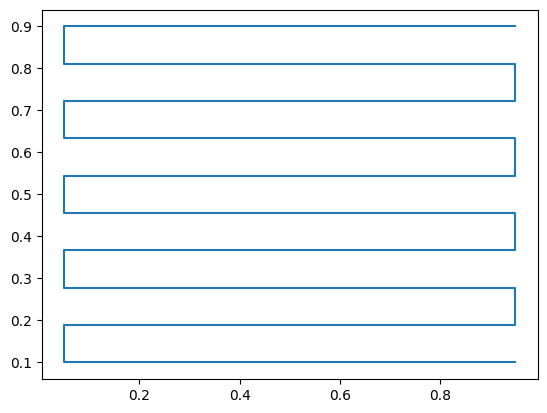

In [37]:
test_zig_zag = generate_horizontal_zigzag_rl(1000)
plt.plot(test_zig_zag[0], test_zig_zag[1])

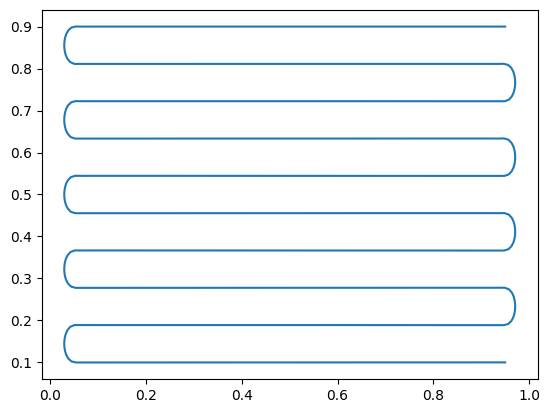

In [38]:
# Smoothening the trajectory
test_smooth = generate_smooth_trajectory(test_zig_zag[0], test_zig_zag[1])
plt.plot(test_smooth[0], test_smooth[1])

In [43]:
# Code to get the distance covered in smoothened trajectory

def compute_trajectory_distance(x, y):
    distance = 0.0
    for i in range(1, len(x)):
        dx = x[i] - x[i-1]
        dy = y[i] - y[i-1]
        distance += np.sqrt(dx*dx + dy*dy)
    return distance

In [46]:
dist = compute_trajectory_distance(test_zig_zag[0], test_zig_zag[1])
print("Distance covered in smoothened trajectory:", dist)

Distance covered in smoothened trajectory: 9.800000000000024


In [39]:
# Computing head direction angles and vectors from trajectory data

def compute_head_dir_angles(x_smooth, y_smooth):
    head_dir_angles = []
    for i in range(len(x_smooth)-1):
        dx = x_smooth[i+1] - x_smooth[i]
        dy = y_smooth[i+1] - y_smooth[i]
        heading_angle = math.atan2(dy, dx) # (range is -pi to pi)
        if heading_angle < 0:
            heading_angle += (2 * math.pi)
        #heading_angle = (heading_angle + 2 * math.pi) % (2 * math.pi) #(range is 0 to 2pi)
        head_dir_angles.append(heading_angle)
    head_dir_angles.append(head_dir_angles[-1])  # Repeat last angle to maintain length
    return head_dir_angles


def compute_head_dir_angles_der(x_smooth, y_smooth):
    head_dir_angles = []
    dx = np.gradient(x_smooth)
    dy = np.gradient(y_smooth)
    head_dir_angles = np.arctan2(dy, dx)
    return head_dir_angles


def compute_head_dir_vectors(x_smooth, y_smooth):
    cos_thetas, sin_thetas = [], []
    for i in range(len(x_smooth)-1):
        dx = x_smooth[i+1] - x_smooth[i]
        dy = y_smooth[i+1] - y_smooth[i]
        #heading_angle = math.atan2(dy, dx)
        norm = np.sqrt(dx**2 + dy**2) + 1e-8
        cos_theta = dx / norm
        sin_theta = dy / norm
        cos_thetas.append(cos_theta)
        sin_thetas.append(sin_theta)
    cos_thetas.append(cos_thetas[-1])  # Repeat last vector to maintain length
    sin_thetas.append(sin_thetas[-1])  # Repeat last vector to maintain length
    return cos_thetas, sin_thetas

def compute_head_dir_vectors_der(x_smooth, y_smooth):
    cos_thetas, sin_thetas = [], []
    dx = np.gradient(x_smooth)
    dy = np.gradient(y_smooth)
    norm = np.sqrt(dx**2 + dy**2) + 1e-8
    cos_thetas = dx / norm
    sin_thetas = dy / norm
    return cos_thetas, sin_thetas
        

In [40]:
# Generating visual cue based on head directions in the trajectory

#Landmarks Clockwise from bottom-left corner

def build_wall_landmarks(n_per_wall = 19):
    pos = np.linspace(0.05, 0.95, n_per_wall)
    landmarks = []

    landmarks.append((0.0, 0.0))
    for y in pos: landmarks.append((0.0, y))
    landmarks.append((0.0, 1.0))
    for x in pos: landmarks.append((x, 1.0))
    landmarks.append((1.0, 1.0))
    for y in reversed(pos): landmarks.append((1.0, y))
    landmarks.append((1.0, 0.0))
    for x in reversed(pos): landmarks.append((x, 0.0))
    
    return np.array(landmarks)

def generate_visual_cue(x_smooth, y_smooth, landmarks, fov=np.pi, eps=1e-6):
    """
    Generate egocentric visual cues as inverse distances (1/d) to landmarks.

    Encoding:
    - Visible landmark: inverse distance (1/d) - farther landmarks have less weight
    - Not visible: 0.0

    Returns
    -------
    egocentric_distances : np.ndarray
        Array of shape (T, L) where T=len(x_smooth), L=len(landmarks).
        Each value is 1/distance for visible landmarks, 0 for non-visible.
    """
    cos_thetas, sin_thetas = compute_head_dir_vectors(x_smooth, y_smooth)
    T = len(x_smooth)
    L = len(landmarks)

    inv_distances = np.zeros((T, L), dtype=np.float32)
    fov_half_cos = math.cos(fov / 2)

    for t in range(T):
        xt, yt = x_smooth[t], y_smooth[t]
        current_head_dir_vector = np.array([cos_thetas[t], sin_thetas[t]])

        for l, (xl, yl) in enumerate(landmarks):
            # Vector from agent to landmark
            r = np.array([xl - xt, yl - yt])
            distance = np.linalg.norm(r)

            # Checking visibility
            dot = np.dot(current_head_dir_vector, r)  # Dot product with vector r
            cos_angle = dot / distance

            if dot > 0 and cos_angle >= fov_half_cos:
                # Store inverse distance: 1/d (farther points have less weight)
                inv_distances[t, l] = 1.0 / distance + eps
            else:
                # Not visible: set to 0
                inv_distances[t, l] = 0.0

    return inv_distances


In [41]:
# Generating limb oscillations with respect to trajectory

#Parameters

am = 0.1 # stride length
L = 0.05 # length of limb
phi = math.pi #phase difference between contralateral limbs
d = 0.05 # spacing between limb pairs

def compute_curvature(x, y):
    dx = np.gradient(x)
    dy = np.gradient(y)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)
    numerator = (dx * ddy - dy * ddx)
    denominator = (dx**2 + dy**2)**1.5 
    # Check if dx and dy are zero anywhere
    if np.any(denominator) == 0:
        raise ValueError("Curvature calculation error: division by zero.")
    else:
        return numerator / denominator
    
def limb_oscillations_with_curvature(time_series, am, L, d, phi, omega, x, y):
    theta_m = am / (4 * L)
    k = compute_curvature(x, y)

    UFL = theta_m * (1 + k*d) * np.sin(omega*time_series)
    UFR = theta_m * (1 - k*d) * np.sin(omega*time_series + phi)
    UHR = theta_m * (1 - k*d) * np.sin(omega*time_series)
    UHL = theta_m * (1 + k*d) * np.sin(omega*time_series + phi)

    return UFL, UFR, UHR, UHL, k

In [ ]:
# Generate data of trajectories and corresponding limb oscillations

def generate_data(num_trajectories):
    '''
    1. Generate smooth trajectory
    2. Generate corresponsing visual cues, head directions
    3. Based on trajectory, generate limb oscillations
    '''

    x_smooth_all, y_smooth_all = [], []
    limb_data_all = []
    hd_angles_all = []
    initial_positions_all = []
    visual_cues_all = []
    cos_thetas_all, sin_thetas_all = [], []
    initial_velocities = []
    avg_velocities = []
    limb_osc_freqs = []
    total_distances = []
    

    for trajectory in range(num_trajectories):
        #limb_osc_freq = np.random.uniform(1, 5)
        #velocity = am * limb_osc_freq
        initial_velocity = np.random.uniform(0.1, 1.0) # running = 2.5
        initial_velocities.append(initial_velocity)
        initial_positions, x_smooth, y_smooth = generate_smooth_trajectory(initial_velocity)
        initial_positions_all.append(initial_positions)

        # Getting velocity from smooth trajectory

        # dx = np.gradient(x_smooth) / dt  # dt = 0.01
        # dy = np.gradient(y_smooth) / dt
        # instantaneous_speed = np.sqrt(dx**2 + dy**2)
        # avg_velocity = np.mean(instantaneous_speed)

        dx = np.diff(x_smooth)  # x[i+1] - x[i] for all i
        dy = np.diff(y_smooth)  # y[i+1] - y[i] for all i
        #segment_distances = np.sqrt(dx**2 + dy**2)  # Distance for each segment
        segment_distances = np.hypot(dx, dy)
        total_distance = np.sum(segment_distances)  # Total path length
        total_distances.append(total_distance)
        avg_velocity = total_distance / total_time
        avg_velocities.append(avg_velocity)

        # velocity = am * limb_osc_freq (stride length * stride frequency)
        limb_osc_freq = avg_velocity / am
        limb_osc_freqs.append(limb_osc_freq)
        omega = 2 * math.pi * limb_osc_freq #angular frequency        
        limb_data = limb_oscillations_with_curvature(time_series, am, L, d, phi, omega, x_smooth, y_smooth)
        
        hd_angles = compute_head_dir_angles_der(x_smooth, y_smooth)
        cos_thetas, sin_thetas = compute_head_dir_vectors_der(x_smooth, y_smooth)
        visual_cue_data = generate_visual_cue(x_smooth, y_smooth, build_wall_landmarks())
        
        x_smooth_all.append(x_smooth)
        y_smooth_all.append(y_smooth)
        cos_thetas_all.append(cos_thetas)
        sin_thetas_all.append(sin_thetas)
        visual_cues_all.append(visual_cue_data)
        limb_data_all.append(limb_data)
        hd_angles_all.append(hd_angles)


    return initial_positions_all, visual_cues_all, limb_data_all, x_smooth_all, y_smooth_all, hd_angles_all, cos_thetas_all, sin_thetas_all, total_distances,initial_velocities, avg_velocities,  limb_osc_freqs
    


In [ ]:

def generate_span_trajectories():
    """Generate 6 specific test trajectories that span the entire grid."""
    test_generators = [
        ("Spiral from center", generate_spiral_from_center),
        ("Spiral from boundary", generate_spiral_from_boundary),
        ("Horizontal zigzag L->R", generate_horizontal_zigzag_lr),
        ("Horizontal zigzag R->L", generate_horizontal_zigzag_rl),
        ("Vertical zigzag B->T", generate_vertical_zigzag_bt),
        ("Vertical zigzag T->B", generate_vertical_zigzag_tb),
    ]
    
    x_smooth_all, y_smooth_all = [], []
    limb_data_all = []
    hd_angles_all = []
    initial_positions_all = []
    visual_cues_all = []
    cos_thetas_all, sin_thetas_all = [], []
    total_distances = []
    avg_velocities = []
    limb_osc_freqs = []
    
    print("Generating 6 test trajectories spanning the grid:")
    for name, generator in test_generators:
        print(f"  - {name}")
        
        # Generate trajectory
        if 'zigzag' in name.lower():
            x_smooth, y_smooth = generator(total_time_steps, n_passes=5)
        else:
            x_smooth, y_smooth = generator(total_time_steps)
        
        initial_positions = np.array([x_smooth[0], y_smooth[0]])
        initial_positions_all.append(initial_positions)
        
        # Calculate velocity from trajectory
        dx = np.diff(x_smooth)
        dy = np.diff(y_smooth)
        segment_distances = np.hypot(dx, dy)
        total_distance = np.sum(segment_distances)
        total_distances.append(total_distance)
        avg_velocity = total_distance / total_time
        avg_velocities.append(avg_velocity)
        
        # Generate limb oscillations
        limb_osc_freq = avg_velocity / am
        limb_osc_freqs.append(limb_osc_freq)
        omega = 2 * math.pi * limb_osc_freq
        limb_data = limb_oscillations_with_curvature(time_series, am, L, d, phi, omega, x_smooth, y_smooth)
        
        # Generate head direction and visual cues
        hd_angles = compute_head_dir_angles_der(x_smooth, y_smooth)
        cos_thetas, sin_thetas = compute_head_dir_vectors_der(x_smooth, y_smooth)
        visual_cue_data = generate_visual_cue(x_smooth, y_smooth, build_wall_landmarks())
        
        x_smooth_all.append(x_smooth)
        y_smooth_all.append(y_smooth)
        cos_thetas_all.append(cos_thetas)
        sin_thetas_all.append(sin_thetas)
        visual_cues_all.append(visual_cue_data)
        limb_data_all.append(limb_data)
        hd_angles_all.append(hd_angles)
    
    # Convert to arrays
    initial_positions_all = np.array(initial_positions_all)
    initial_positions_all_expanded = np.repeat(initial_positions_all[:, :, np.newaxis], 1000, axis=2)
    initial_positions_transpose = initial_positions_all_expanded.transpose(0, 2, 1)
    
    visual_cues_all = np.array(visual_cues_all)
    limb_data_all = np.array(limb_data_all)
    limb_data_with_curvature = limb_data_all.transpose(0, 2, 1)
    
    x_smooth_all = np.array(x_smooth_all)
    y_smooth_all = np.array(y_smooth_all)
    hd_angles_all = np.array(hd_angles_all)
    cos_thetas_all = np.array(cos_thetas_all)
    sin_thetas_all = np.array(sin_thetas_all)
    
    visual_limb_data = np.concatenate((initial_positions_transpose, visual_cues_all, limb_data_with_curvature), axis=2)
    trajectory_data = np.stack((x_smooth_all, y_smooth_all, hd_angles_all, cos_thetas_all, sin_thetas_all), axis=-1)
    
    return visual_limb_data, trajectory_data, total_distances, avg_velocities, limb_osc_freqs

# Generate training data (random trajectories)
#train_visual_limb_data, train_trajectory_data, train_total_distances, train_initial_velocities, train_avg_velocities, train_limb_osc_freqs = get_data(500)

# Generate test data (6 specific trajectories spanning the grid)
test_visual_limb_data, test_trajectory_data, test_total_distances, test_avg_velocities, test_limb_osc_freqs = generate_test_trajectories_spanning_grid()

In [ ]:
# Generate and combine data into usable format

def get_data(num_trajectories):
    initial_positions_all, visual_cues_all, limb_data_all, x_smooth_all, y_smooth_all, hd_angles_all, cos_thetas_all, sin_thetas_all, total_distances, initial_velocities, avg_velocities,  limb_osc_freqs = generate_data(num_trajectories)

    initial_positions_all = np.array(initial_positions_all)
    initial_positions_all_expanded = np.repeat(initial_positions_all[:, :, np.newaxis], 1000, axis=2)
    #print("Initial Positions expanded shape:", initial_positions_all_expanded.shape)
    initial_positions_transpose = initial_positions_all_expanded.transpose(0, 2, 1)
    #print("Initial Positions transposed shape:", initial_positions_transpose.shape)
    
    visual_cues_all = np.array(visual_cues_all)
    # visual_cues_all is now (num_trajectories, time_steps, n_landmarks) with inverse distances
    # No need to reshape - it's already in the right format

    limb_data_all = np.array(limb_data_all)
    limb_data_with_curvature = limb_data_all.transpose(0, 2, 1)  # (num_trajectories, time_steps, 4 limbs + curvature)

    x_smooth_all = np.array(x_smooth_all)
    y_smooth_all = np.array(y_smooth_all)

    hd_angles_all = np.array(hd_angles_all)
    cos_thetas_all = np.array(cos_thetas_all)
    sin_thetas_all = np.array(sin_thetas_all)

    #print(visual_cues_all.shape, limb_data_all.shape, x_smooth_all.shape, y_smooth_all.shape, hd_angles_all.shape, cos_thetas_all.shape, sin_thetas_all.shape)

    
    
    visual_limb_data = np.concatenate((initial_positions_transpose, visual_cues_all, limb_data_with_curvature), axis=2)
    print(visual_limb_data.shape) # (num_trajectories, 1000, 2 + 80 + 5)

    trajectory_data = np.stack((x_smooth_all, y_smooth_all, hd_angles_all, cos_thetas_all, sin_thetas_all), axis=-1)
    trajectory_data = np.array(trajectory_data)
    print(trajectory_data.shape)


    return visual_limb_data, trajectory_data, total_distances, initial_velocities, avg_velocities, limb_osc_freqs

In [45]:
#print(train_visual_limb_data.shape)
#print(train_trajectory_data.shape)
# Input features (inclusive):
# 0-1: Initial position (x, y)
# 2-81: Visual Cue (80 landmarks, each with inverse distance 1/d, 0 if not visible)
# 82-85: Limb Oscillations (UFL, UFR, UHR, UHL)
# 86: Curvature

print(test_visual_limb_data.shape)
print(test_trajectory_data.shape)
# Output features:
# 0: X position
# 1: Y position
# 2: HD angle
# 3: HD cos vector
# 4: HD sin vector

print("\nTest trajectories are 6 specific patterns spanning the entire grid:")
print("  1. Spiral from center (outward)")
print("  2. Spiral from boundary (inward)")
print("  3. Horizontal zigzag left-to-right")
print("  4. Horizontal zigzag right-to-left")
print("  5. Vertical zigzag bottom-to-top")
print("  6. Vertical zigzag top-to-bottom")

(6, 1000, 87)
(6, 1000, 5)

Test trajectories are 6 specific patterns spanning the entire grid:
  1. Spiral from center (outward)
  2. Spiral from boundary (inward)
  3. Horizontal zigzag left-to-right
  4. Horizontal zigzag right-to-left
  5. Vertical zigzag bottom-to-top
  6. Vertical zigzag top-to-bottom


In [47]:
initial_pos_start = 0
initial_pos_end = 2
visual_start = initial_pos_end
n_visual = 80  # Now just 80 landmarks (1 value per landmark: inverse distance)
visual_end = visual_start + n_visual
limb_osc_start = visual_end
n_limb_osc = 4
limb_osc_end = limb_osc_start + n_limb_osc
curvature_start = limb_osc_end
curvature_end = curvature_start + 1

n_pos = 2
n_hd_angle = 1
n_hd_vec = 2

def build_io_dicts(visual_limb_data, trajectory_data, n_visual=80):
    
    N, T, F = visual_limb_data.shape
    inputs = {}

    inputs["initial_pos"] = visual_limb_data[:, :, initial_pos_start:initial_pos_end]            # (N, T, 2)
    # visual cues: now just inverse distances (1/d) for each landmark

    n_visual = min(n_visual, F)
    inputs["visual_cue"] = visual_limb_data[:, :, visual_start:visual_end]            # (N, T, n_visual)
    # limb oscillations (next up to 4 channels)

    limb_start = n_visual+2
    limb_end = min(limb_start + n_limb_osc, F)
    inputs["limb_osc"] = visual_limb_data[:, :, limb_osc_start:limb_osc_end]    # (N, T, <=4)

    # curvature 
    inputs["curvature"] = visual_limb_data[:, :, curvature_start:curvature_end]  # (N, T, 1)

    # Outputs
    outputs = {}
    D = trajectory_data.shape[2]

    # position (x,y)
    outputs["pos"] = trajectory_data[:, :, :2]                          # (N, T, 2)

    # hd angle if present (single scalar per timestep)
    outputs["hd_angle"] = trajectory_data[:, :, 2:3]                # (N, T, 1)


    outputs["hd_cos"] = trajectory_data[:, :, 3:4]
    outputs["hd_sin"] = trajectory_data[:, :, 4:5]
    outputs["hd_vec"] = np.concatenate((outputs["hd_cos"], outputs["hd_sin"]), axis=-1)  # (N, T, 2)

    return inputs, outputs

# Build dicts and show shapes
#train_inputs, train_outputs = build_io_dicts(train_visual_limb_data, train_trajectory_data)
#print("Inputs:", {k: v.shape for k, v in train_inputs.items()})
#print("Outputs:", {k: v.shape for k, v in train_outputs.items()})

test_inputs, test_outputs = build_io_dicts(test_visual_limb_data, test_trajectory_data)
print("Test Inputs:", {k: v.shape for k, v in test_inputs.items()})
print("Test Outputs:", {k: v.shape for k, v in test_outputs.items()})

Test Inputs: {'initial_pos': (6, 1000, 2), 'visual_cue': (6, 1000, 80), 'limb_osc': (6, 1000, 4), 'curvature': (6, 1000, 1)}
Test Outputs: {'pos': (6, 1000, 2), 'hd_angle': (6, 1000, 1), 'hd_cos': (6, 1000, 1), 'hd_sin': (6, 1000, 1), 'hd_vec': (6, 1000, 2)}


#### Stability Checks

In [48]:
# Checking for any zero gradients in x and y positions
zero_grad_counter = 0


for traj in range(test_trajectory_data.shape[0]):
    dx = np.gradient(test_trajectory_data[traj, :, 0])
    dy = np.gradient(test_trajectory_data[traj, :, 1])
    #print(f'Trajectory {traj}: min dx = {np.min(dx)}, min dy = {np.min(dy)}')
    
    if np.min(dx) == 0 or np.min(dy) == 0:
        #print(f'Zero gradient found in trajectory {traj}')
        zero_grad_counter += 1
    # else:
        #print(f'No zero gradient in trajectory {traj}')
print(f'Total trajectories with zero gradients: {zero_grad_counter}')

Total trajectories with zero gradients: 4


Maximum curvature across all trajectories: 95.61143795931079


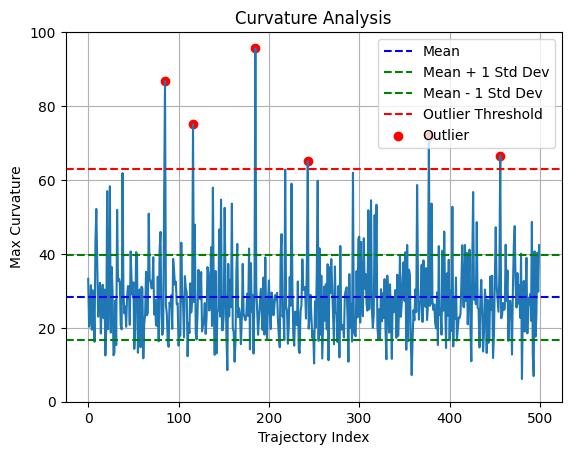

In [19]:
# Checking curvature values to prevent shooting up

max_all = 0
max_ks = []
#print("Checking curvature values for training data...")
for traj in range(train_trajectory_data.shape[0]):
    k = train_inputs["curvature"][traj, :, 0]
    max_k = np.max(np.abs(k))
    max_ks.append(max_k)
    #print(f'Trajectory {traj}: max curvature = {max_k}')
    if max_k > max_all:
        max_all = max_k
print(f'Maximum curvature across all trajectories: {max_all}')

plt.plot(max_ks)

# Calculate mean and standard deviation of curvature values
mean_k = np.mean(max_ks)
std_k = np.std(max_ks)

# Identify outliers (values beyond mean ± 3*std)
outliers = [k for k in max_ks if k > mean_k + 3 * std_k or k < mean_k - 3 * std_k]

# Plot mean and standard deviation
plt.axhline(mean_k, color='blue', linestyle='--', label='Mean')
plt.axhline(mean_k + std_k, color='green', linestyle='--', label='Mean + 1 Std Dev')
plt.axhline(mean_k - std_k, color='green', linestyle='--', label='Mean - 1 Std Dev')
plt.axhline(mean_k + 3 * std_k, color='red', linestyle='--', label='Outlier Threshold')
#plt.axhline(mean_k - 3 * std_k, color='red', linestyle='--')

# Highlight outliers
for i, k in enumerate(max_ks):
    if k in outliers:
        plt.scatter(i, k, color='red', label='Outlier' if 'Outlier' not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title("Curvature Analysis")
plt.ylim(0, 100)
plt.xlabel("Trajectory Index")
plt.ylabel("Max Curvature")
plt.legend()
plt.grid()
plt.show()



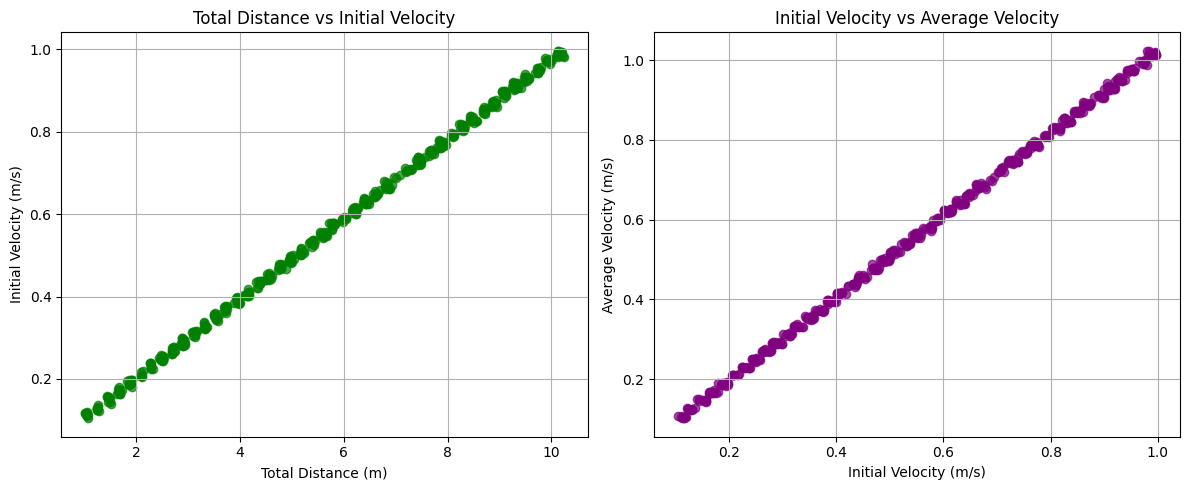

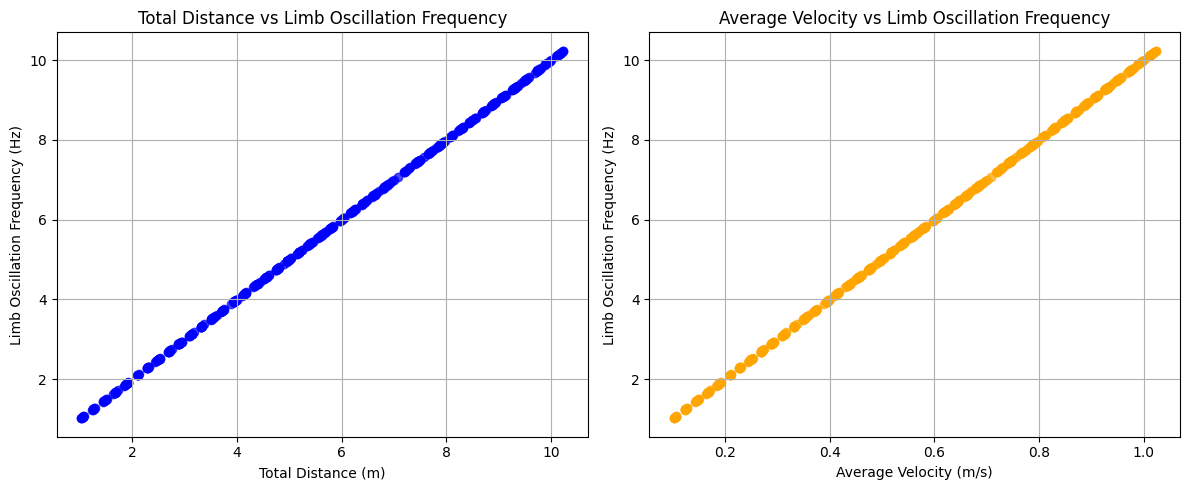

In [20]:
# Verifying kinematics relationships in data generated

def verify_kinematics(train_total_distances, train_initial_velocities, 
                      train_avg_velocities, train_limb_osc_freqs):

    # -------- Figure 1 --------
    plt.figure(figsize=(12, 5))

    # Total Distance vs Initial Velocity
    plt.subplot(1, 2, 1)
    plt.scatter(train_total_distances, train_initial_velocities, 
                color='green', alpha=0.7)
    plt.title('Total Distance vs Initial Velocity')
    plt.xlabel('Total Distance (m)')
    plt.ylabel('Initial Velocity (m/s)')
    plt.grid()

    # Initial Velocity vs Average Velocity
    plt.subplot(1, 2, 2)
    plt.scatter(train_initial_velocities, train_avg_velocities, 
                color='purple', alpha=0.7)
    plt.title('Initial Velocity vs Average Velocity')
    plt.xlabel('Initial Velocity (m/s)')
    plt.ylabel('Average Velocity (m/s)')
    plt.grid()

    plt.tight_layout()
    plt.show()

    # -------- Figure 2 --------
    plt.figure(figsize=(12, 5))

    # Total Distance vs Limb Oscillation Frequency
    plt.subplot(1, 2, 1)
    plt.scatter(train_total_distances, train_limb_osc_freqs, 
                color='blue', alpha=0.7)
    plt.title('Total Distance vs Limb Oscillation Frequency')
    plt.xlabel('Total Distance (m)')
    plt.ylabel('Limb Oscillation Frequency (Hz)')
    plt.grid()

    # Average Velocity vs Limb Oscillation Frequency
    plt.subplot(1, 2, 2)
    plt.scatter(train_avg_velocities, train_limb_osc_freqs, 
                color='orange', alpha=0.7)
    plt.title('Average Velocity vs Limb Oscillation Frequency')
    plt.xlabel('Average Velocity (m/s)')
    plt.ylabel('Limb Oscillation Frequency (Hz)')
    plt.grid()

    plt.tight_layout()
    plt.show()

verify_kinematics(train_total_distances, train_initial_velocities, 
                  train_avg_velocities, train_limb_osc_freqs)

#### Plotting Data

In [140]:
def plot_data(visual_limb_data, trajectory_data, distances, initial_velocities, avg_velocities, limb_osc_freqs, time_series, fov=np.pi, fov_radius=0.3):
    for i in range(5):
        traj_index = np.random.randint(0, len(trajectory_data))
        landmarks = build_wall_landmarks()
        
        # Get data for current trajectory
        coordinate_data = train_outputs["pos"][traj_index]
        hd_vector_data = train_outputs["hd_vec"][traj_index]
        x_coords = coordinate_data[:, 0]
        y_coords = coordinate_data[:, 1]
        cos_thetas = hd_vector_data[:, 0]
        sin_thetas = hd_vector_data[:, 1]
        limb_oscillations = train_inputs["limb_osc"][traj_index]
        UFL_traj, UFR_traj, UHR_traj, UHL_traj = limb_oscillations.T
        k_traj = train_inputs["curvature"][traj_index]
        
        # Get visual cue data for current trajectory
        # Shape: [T, 80] where 80 landmarks, each has inverse distance (1/d)
        visual_cue = train_inputs["visual_cue"][traj_index]  # (T, 80)
        
        # Create a 2x2 grid
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [1, 1.5]})
        fig.suptitle(f"Trajectory {traj_index+1}", fontsize=16)
        
        # Retrieve precomputed trajectory distance and initial velocity
        initial_position = train_inputs["initial_pos"][traj_index][0]
        trajectory_distance = distances[traj_index]
        initial_velocity = initial_velocities[traj_index]
        
        # Calculate average velocity
        average_velocity = avg_velocities[traj_index]
        limb_osc_freq = limb_osc_freqs[traj_index]
        
        # Print the calculated values
        print(f"Initial Position: ({initial_position})")
        print(f"Trajectory Distance: {trajectory_distance:.2f}")
        print(f"Initial Velocity: {initial_velocity:.2f}")
        print(f"Average Velocity: {average_velocity:.2f}")
        print(f"Limb Oscillation Frequency: {limb_osc_freq:.2f}")

        # --- Top-left: Trajectory in grid with FOV ---
        # Pick a random timestep to show FOV
        t = np.random.randint(0, len(x_coords))
        xt, yt = x_coords[t], y_coords[t]
        head_vec = np.array([cos_thetas[t], sin_thetas[t]])
        
        # Extract visibility from visual cue at time t
        # visual_cue_inverse_dist[t, :] contains inverse distances for all 80 landmarks
        # If inverse distance > 0, landmark is visible
        inverse_dists_at_t = visual_cue[t, :]  # (80,)
        visible = inverse_dists_at_t > 0
        
        # Plot landmarks and trajectory
        axes[0, 0].scatter(landmarks[~visible, 0], landmarks[~visible, 1],
                          color='lightgray', s=30, label='Not Visible', alpha=0.5)
        
        # For visible landmarks, use color to indicate inverse distance (fixed size)
        if np.any(visible):
            vis_inv_dists = inverse_dists_at_t[visible]
            scatter = axes[0, 0].scatter(landmarks[visible, 0], landmarks[visible, 1],
                              c=vis_inv_dists, s=30, cmap='hot', 
                              label='Visible', zorder=5, edgecolors='black', linewidths=0.5,
                              vmin=0, vmax=np.max(vis_inv_dists))
            # Add colorbar for inverse distance
            cbar = plt.colorbar(scatter, ax=axes[0, 0], fraction=0.046, pad=0.04)
            cbar.set_label('1/d (Inverse Distance)', rotation=270, labelpad=15, fontsize=9)
        
        axes[0, 0].plot(x_coords, y_coords, color='blue', label='Trajectory', linewidth=1.5)
        
        # Plot head direction arrows
        for j in range(0, len(x_coords), 50):  # every 50 steps
            axes[0, 0].arrow(x_coords[j], y_coords[j],
                    0.1 * cos_thetas[j], 0.1 * sin_thetas[j],
                    color='green', head_width=0.02, alpha=0.7)
            
        # Plot agent and FOV cone
        axes[0, 0].scatter(xt, yt, color='orange', s=100, zorder=10, edgecolors='black', linewidths=1)
        angle = math.atan2(head_vec[1], head_vec[0])
        left_angle = angle - fov/2
        right_angle = angle + fov/2
        
        # FOV cone edges
        axes[0, 0].plot([xt, xt + fov_radius * math.cos(left_angle)],
                       [yt, yt + fov_radius * math.sin(left_angle)],
                       'k--', alpha=0.5, linewidth=1)
        axes[0, 0].plot([xt, xt + fov_radius * math.cos(right_angle)],
                       [yt, yt + fov_radius * math.sin(right_angle)],
                       'k--', alpha=0.5, linewidth=1)
        
        # Shaded FOV cone
        theta = np.linspace(left_angle, right_angle, 30)
        axes[0, 0].fill(xt + fov_radius * np.cos(theta),
                       yt + fov_radius * np.sin(theta),
                       color='yellow', alpha=0.2)
        
        axes[0, 0].set_title(f'Trajectory & FOV at t={t} (timestep {t})')
        axes[0, 0].set_xlabel('X Position')
        axes[0, 0].set_ylabel('Y Position')
        axes[0, 0].set_xlim(0, 1)
        axes[0, 0].set_ylim(0, 1)
        axes[0, 0].grid(alpha=0.3)
        axes[0, 0].legend(loc='upper right', fontsize=8)
        axes[0, 0].set_aspect('equal')

        # --- Bottom-left: Position vs time ---
        axes[1, 0].plot(time_series, x_coords, label='X Position', color='orange', linewidth=1.5)
        axes[1, 0].plot(time_series, y_coords, label='Y Position', color='green', linewidth=1.5)
        axes[1, 0].axvline(time_series[t], color='red', linestyle=':', alpha=0.5, label=f'Current t={time_series[t]:.2f}s')
        axes[1, 0].set_title('Position vs Time')
        axes[1, 0].set_xlabel('Time (s)')
        axes[1, 0].set_ylabel('Position')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

        # --- Right column (span): Limb oscillations ---
        ax_right = axes[0, 1]
        ax_right.plot(time_series, UFL_traj[:len(time_series)], label='UFL', color='red', linewidth=1.5)
        ax_right.plot(time_series, UFR_traj[:len(time_series)], label='UFR', color='blue', linewidth=1.5)
        ax_right.plot(time_series, UHR_traj[:len(time_series)], label='UHR', color='green', linewidth=1.5)
        ax_right.plot(time_series, UHL_traj[:len(time_series)], label='UHL', color='purple', linewidth=1.5)
        ax_right.axvline(time_series[t], color='red', linestyle=':', alpha=0.5)
        
        ax_right.set_title(f'Limb Oscillations vs Time (freq={limb_osc_freq:.2f} Hz)')
        ax_right.set_xlabel('Time (s)')
        ax_right.set_ylabel('Limb Angle (rad)')
        ax_right.legend()
        ax_right.grid(alpha=0.3)

        # --- Bottom-right: Curvature ---
        ax_bottom_right = axes[1, 1]
        ax_bottom_right.plot(time_series, k_traj[:len(time_series)], 
                           label='Curvature (k)', color='black', linestyle='-', linewidth=1.5, alpha=0.8)
        ax_bottom_right.axvline(time_series[t], color='red', linestyle=':', alpha=0.5)
        ax_bottom_right.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax_bottom_right.set_ylabel('Curvature (1/m)')
        ax_bottom_right.set_xlabel('Time (s)')
        ax_bottom_right.set_title('Path Curvature vs Time')
        ax_bottom_right.legend()
        ax_bottom_right.grid(alpha=0.3)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        # Print visibility statistics
        num_visible = np.sum(visible)
        print(f"  Visible landmarks at t={t}: {num_visible}/80 ({num_visible/80*100:.1f}%)")

Initial Position: ([0.58678399 0.13146227])
Trajectory Distance: 5.80
Initial Velocity: 0.56
Average Velocity: 0.58
Limb Oscillation Frequency: 5.80


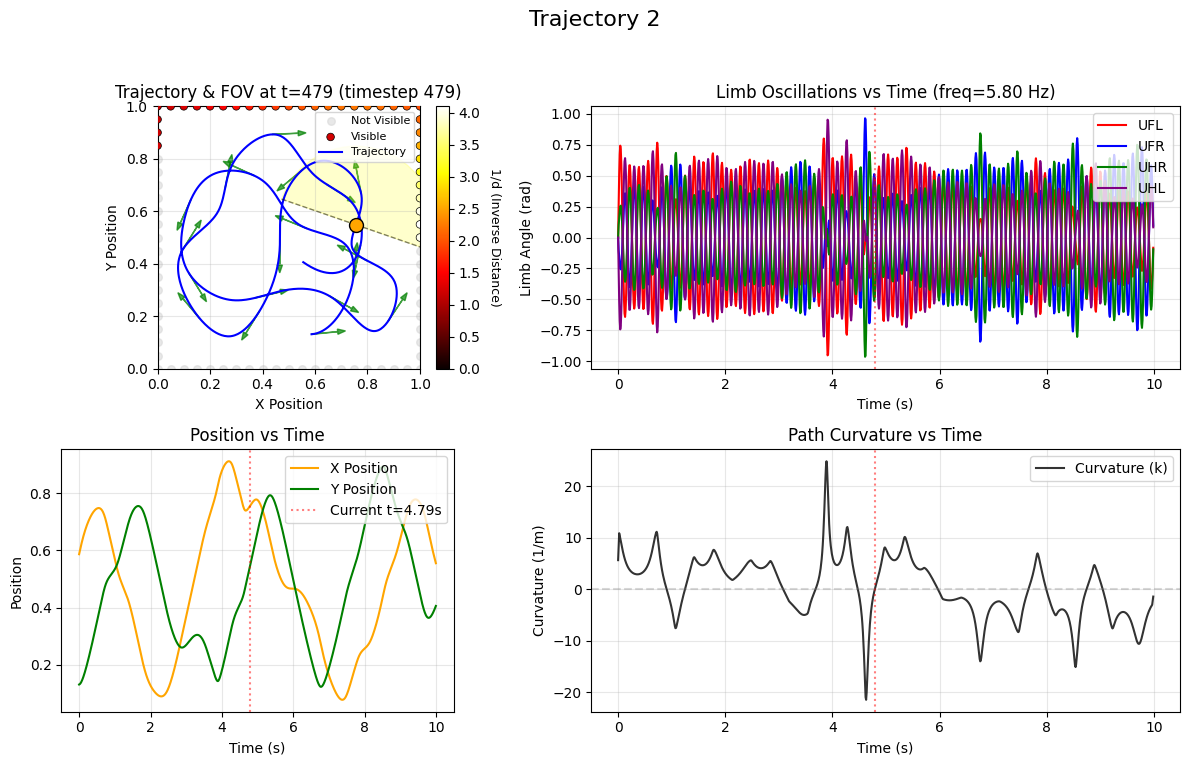

  Visible landmarks at t=479: 34/80 (42.5%)
Initial Position: ([0.56956636 0.8190596 ])
Trajectory Distance: 10.15
Initial Velocity: 0.99
Average Velocity: 1.01
Limb Oscillation Frequency: 10.15


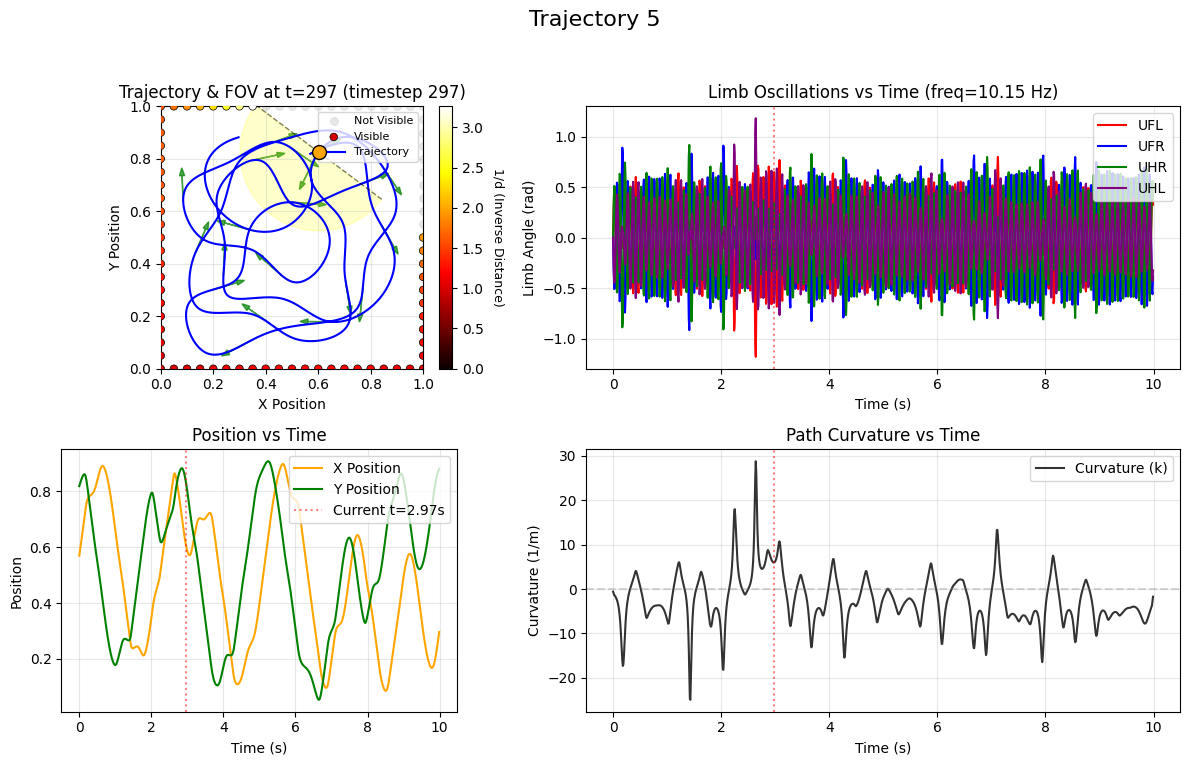

  Visible landmarks at t=297: 58/80 (72.5%)
Initial Position: ([0.64251355 0.36338201])
Trajectory Distance: 8.24
Initial Velocity: 0.80
Average Velocity: 0.82
Limb Oscillation Frequency: 8.24


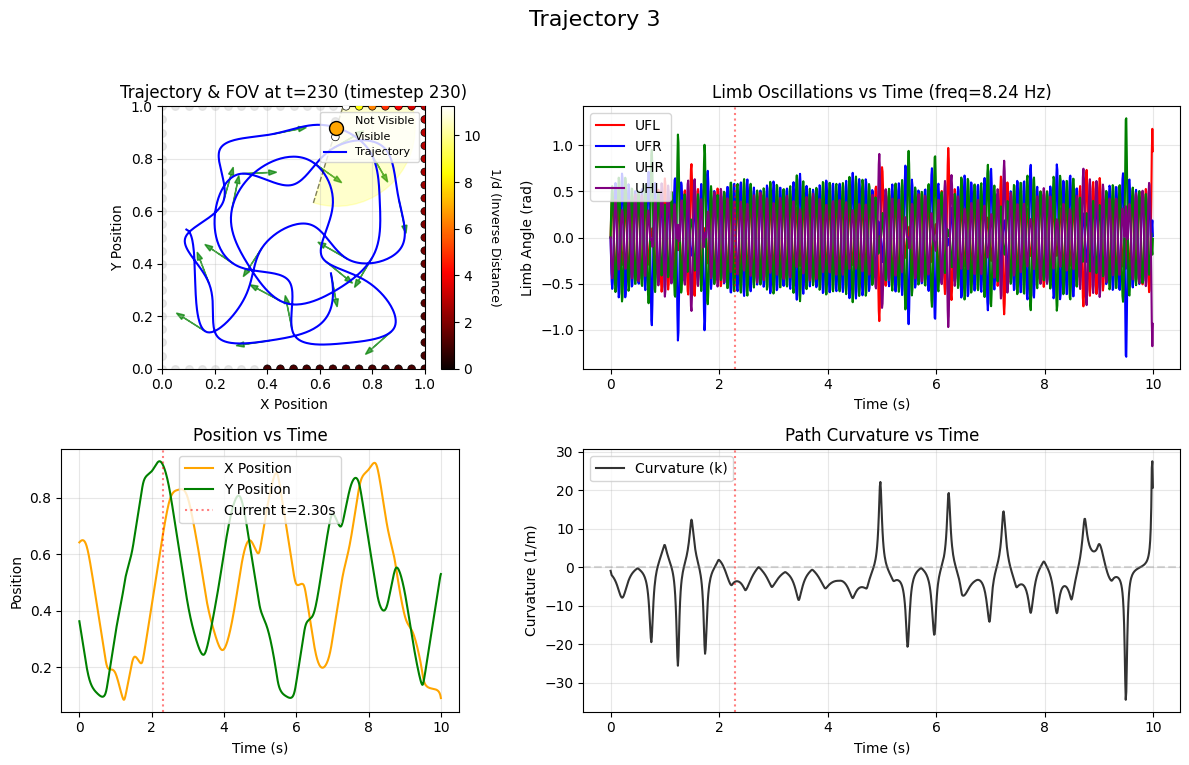

  Visible landmarks at t=230: 39/80 (48.8%)
Initial Position: ([0.78366862 0.73455925])
Trajectory Distance: 2.24
Initial Velocity: 0.23
Average Velocity: 0.22
Limb Oscillation Frequency: 2.24


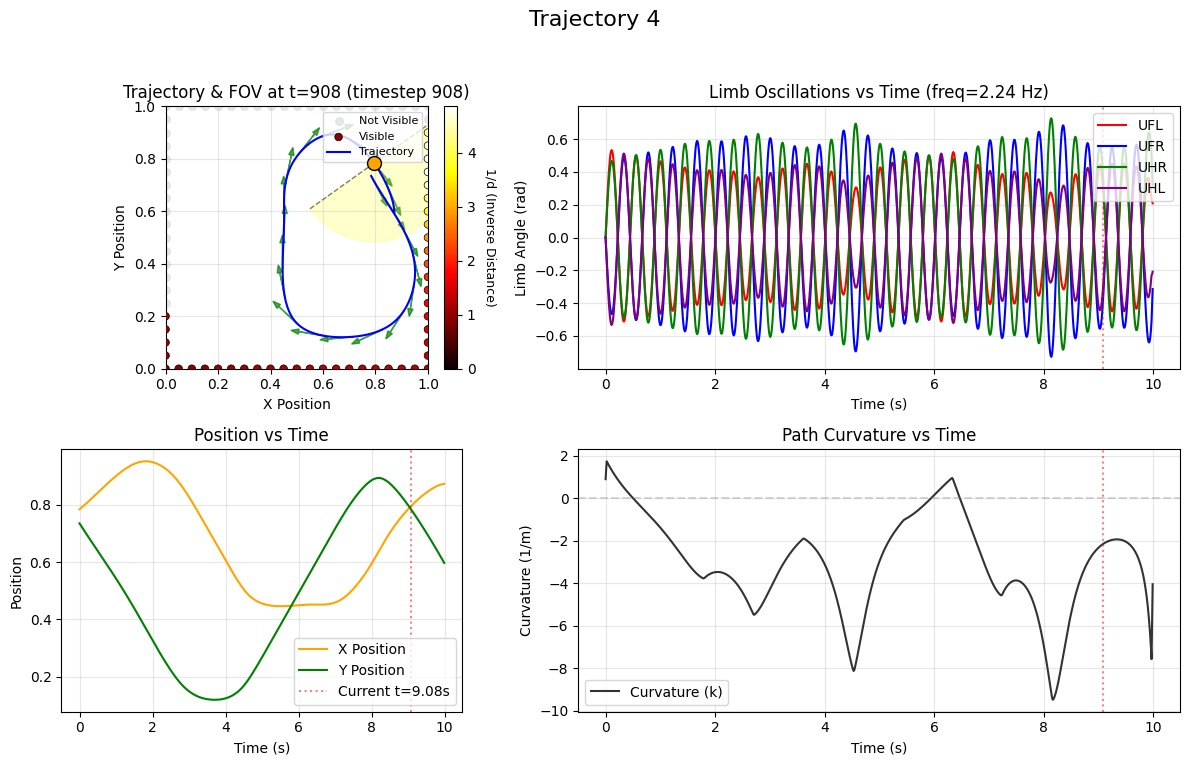

  Visible landmarks at t=908: 43/80 (53.8%)
Initial Position: ([0.78366862 0.73455925])
Trajectory Distance: 2.24
Initial Velocity: 0.23
Average Velocity: 0.22
Limb Oscillation Frequency: 2.24


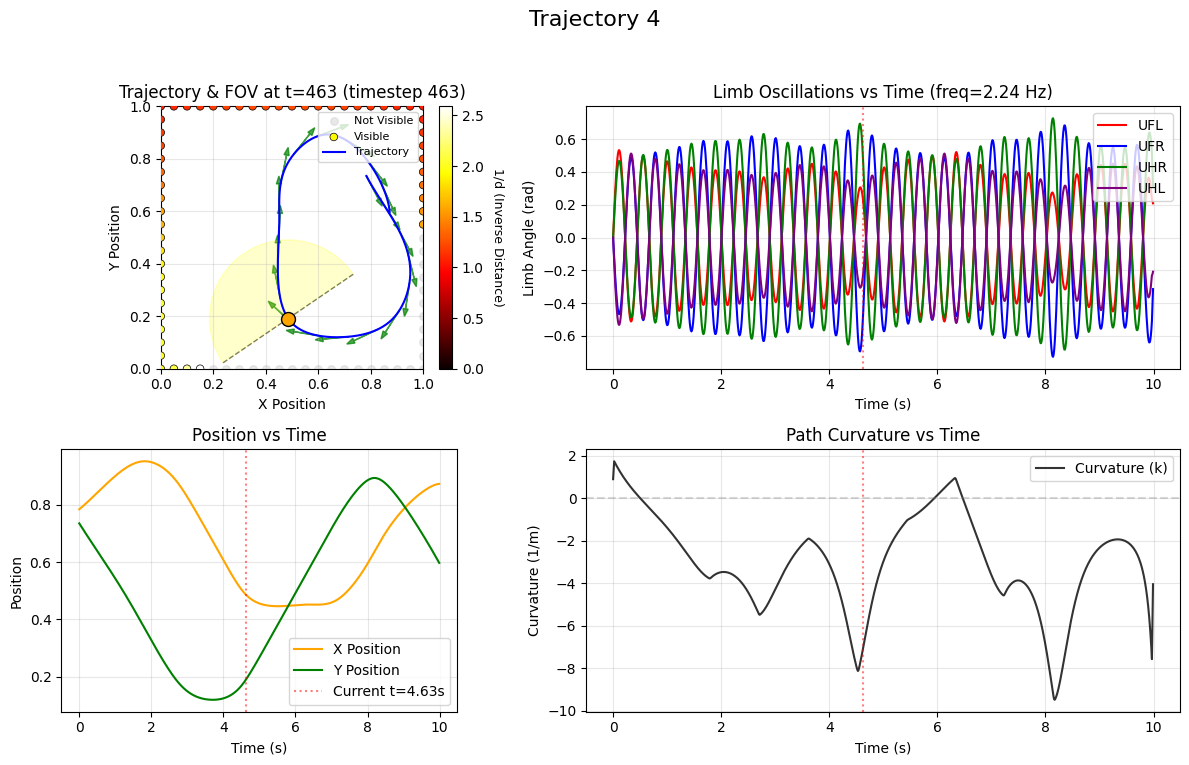

  Visible landmarks at t=463: 53/80 (66.2%)


In [141]:
plot_data(train_inputs, train_outputs, train_total_distances, train_initial_velocities, train_avg_velocities, train_limb_osc_freqs, time_series)

In [142]:
def create_occupancy_map(trajectory_data, n_bins=20):
    """
    Create an occupancy map showing how many times each grid bin was visited.
    
    Parameters:
    -----------
    trajectory_data : dict with 'pos' key containing (N, T, 2) array
    n_bins : int, number of bins in each dimension
    
    Returns:
    --------
    occupancy_map : 2D array of shape (n_bins, n_bins)
    """
    # Extract all positions from all trajectories
    positions = trajectory_data["pos"]  # Shape: (N_trajectories, T_timesteps, 2)
    N, T, _ = positions.shape
    
    # Flatten to get all (x, y) points
    x_all = positions[:, :, 0].flatten()  # All x coordinates
    y_all = positions[:, :, 1].flatten()  # All y coordinates
    
    # Create 2D histogram (occupancy map)
    occupancy_map, x_edges, y_edges = np.histogram2d(
        x_all, y_all, 
        bins=n_bins, 
        range=[[0, 1], [0, 1]]
    )
    
    return occupancy_map.T, x_edges, y_edges  # Transpose for correct orientation


def plot_occupancy_map(occupancy_map, x_edges, y_edges, title="Occupancy Map"):
    """
    Plot the occupancy map as a heatmap.
    """
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Plot heatmap
    im = ax.imshow(
        occupancy_map, 
        origin='lower',
        extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
        cmap='hot',
        interpolation='nearest'
    )
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Visit Count', rotation=270, labelpad=20)
    
    # Labels and title
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Add text with statistics
    total_visits = np.sum(occupancy_map)
    mean_visits = np.mean(occupancy_map)
    std_visits = np.std(occupancy_map)
    min_visits = np.min(occupancy_map)
    max_visits = np.max(occupancy_map)
    
    stats_text = f'Total: {int(total_visits)}\nMean: {mean_visits:.1f}\nStd: {std_visits:.1f}\nMin: {int(min_visits)}\nMax: {int(max_visits)}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print coverage statistics
    n_bins = occupancy_map.shape[0]
    total_bins = n_bins * n_bins
    visited_bins = np.sum(occupancy_map > 0)
    coverage_percent = (visited_bins / total_bins) * 100
    
    print(f"\n{'='*50}")
    print(f"Occupancy Map Statistics ({n_bins}x{n_bins} bins)")
    print(f"{'='*50}")
    print(f"Total bins: {total_bins}")
    print(f"Visited bins: {visited_bins}")
    print(f"Coverage: {coverage_percent:.2f}%")
    print(f"Unvisited bins: {total_bins - visited_bins}")
    print(f"Mean visits per bin: {mean_visits:.2f}")
    print(f"Std visits per bin: {std_visits:.2f}")
    print(f"Min visits: {int(min_visits)}")
    print(f"Max visits: {int(max_visits)}")
    print(f"{'='*50}\n")


def compare_occupancy_maps(train_outputs, test_outputs, n_bins=20):
    """
    Compare occupancy maps for training and test datasets side by side.
    """
    # Create occupancy maps
    train_occ, train_x, train_y = create_occupancy_map(train_outputs, n_bins)
    test_occ, test_x, test_y = create_occupancy_map(test_outputs, n_bins)
    
    # Plot side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Shared colorbar range
    vmin = 0
    vmax = max(train_occ.max(), test_occ.max())
    
    # Train map
    im1 = axes[0].imshow(train_occ, origin='lower', 
                         extent=[0, 1, 0, 1], cmap='hot', 
                         interpolation='nearest', vmin=vmin, vmax=vmax)
    axes[0].set_xlabel('X Position')
    axes[0].set_ylabel('Y Position')
    axes[0].set_title(f'Training Set Occupancy\n({train_outputs["pos"].shape[0]} trajectories)')
    axes[0].grid(True, alpha=0.3)
    
    # Test map
    im2 = axes[1].imshow(test_occ, origin='lower', 
                         extent=[0, 1, 0, 1], cmap='hot', 
                         interpolation='nearest', vmin=vmin, vmax=vmax)
    axes[1].set_xlabel('X Position')
    axes[1].set_ylabel('Y Position')
    axes[1].set_title(f'Test Set Occupancy\n({test_outputs["pos"].shape[0]} trajectories)')
    axes[1].grid(True, alpha=0.3)
    
    # Shared colorbar
    fig.colorbar(im1, ax=axes, label='Visit Count', fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nTRAINING SET:")
    visited_train = np.sum(train_occ > 0)
    coverage_train = (visited_train / (n_bins**2)) * 100
    print(f"Coverage: {coverage_train:.2f}% ({visited_train}/{n_bins**2} bins)")
    
    print("\nTEST SET:")
    visited_test = np.sum(test_occ > 0)
    coverage_test = (visited_test / (n_bins**2)) * 100
    print(f"Coverage: {coverage_test:.2f}% ({visited_test}/{n_bins**2} bins)")

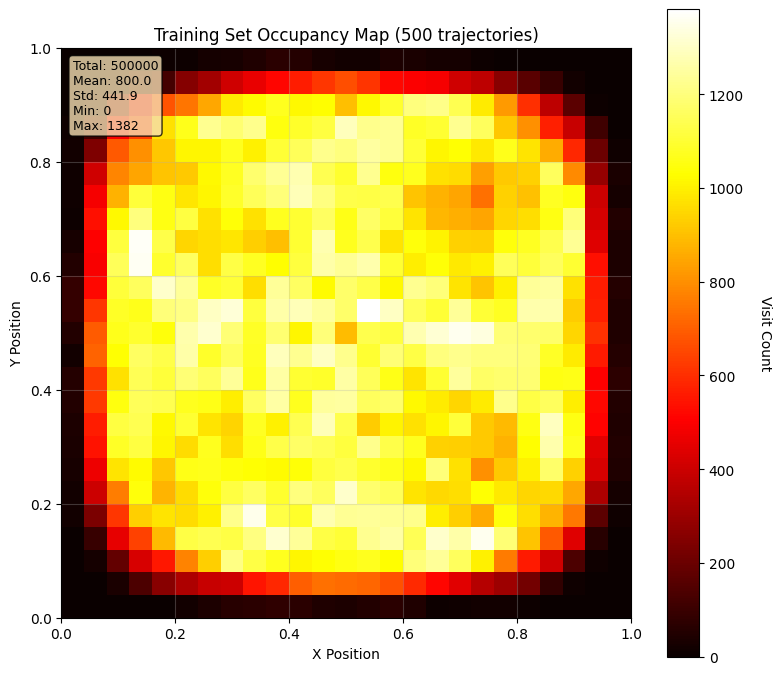


Occupancy Map Statistics (25x25 bins)
Total bins: 625
Visited bins: 598
Coverage: 95.68%
Unvisited bins: 27
Mean visits per bin: 800.00
Std visits per bin: 441.87
Min visits: 0
Max visits: 1382



In [143]:
train_occ, train_x, train_y = create_occupancy_map(train_outputs, n_bins=25)
plot_occupancy_map(train_occ, train_x, train_y, title="Training Set Occupancy Map (500 trajectories)")

In [ ]:
# Occupancy map for test set (6 specific trajectories spanning the grid)
test_occ, test_x, test_y = create_occupancy_map(test_outputs, n_bins=25)
plot_occupancy_map(test_occ, test_x, test_y, title="Test Set Occupancy Map (6 spanning trajectories)")

#### Save and Load Data

In [145]:
# Saving Data

data_path = '0_agent_data/'

train_visual_limb_data_file = '13_dec_train_visual_limb_data.pkl'
train_traj_data_file = '13_dec_train_traj_data.pkl'

test_visual_limb_data_file = '13_dec_test_visual_limb_data.pkl'
test_traj_data_file = '13_dec_test_traj_data.pkl'

with open(f'{data_path}{train_visual_limb_data_file}', 'wb') as f:
    pickle.dump(train_visual_limb_data, f)
    
with open(f'{data_path}{train_traj_data_file}', 'wb') as f:
    pickle.dump(train_trajectory_data, f)

with open(f'{data_path}{test_visual_limb_data_file}', 'wb') as f:
    pickle.dump(test_visual_limb_data, f)

with open(f'{data_path}{test_traj_data_file}', 'wb') as f:
    pickle.dump(test_trajectory_data, f)


In [146]:
# Loading Data

data_path = '0_agent_data/'

train_visual_limb_data_file = '13_dec_train_visual_limb_data.pkl'
train_traj_data_file = '13_dec_train_traj_data.pkl'

test_visual_limb_data_file = '13_dec_test_visual_limb_data.pkl'
test_traj_data_file = '13_dec_test_traj_data.pkl'
with open(f'{data_path}{train_visual_limb_data_file}', 'rb') as f:
    train_visual_limb_data = pickle.load(f)

with open(f'{data_path}{train_traj_data_file}', 'rb') as f:
    train_trajectory_data = pickle.load(f)

with open(f'{data_path}{test_visual_limb_data_file}', 'rb') as f:
    test_visual_limb_data = pickle.load(f)

with open(f'{data_path}{test_traj_data_file}', 'rb') as f:
    test_trajectory_data = pickle.load(f)

